### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [79]:
import tensorflow as tf
from tensorflow.keras import layers, Model, losses

In [67]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/ipl_data.csv')

In [5]:
df.shape

(76014, 15)

In [60]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


### Step 3: Exploaring Data

#### Basic Info

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mid,76014.0,308.627740,178.156878,1.0,154.0,308.0,463.0,617.0
runs,76014.0,74.889349,48.823327,0.0,34.0,70.0,111.0,263.0
wickets,76014.0,2.415844,2.015207,0.0,1.0,2.0,4.0,10.0
overs,76014.0,9.783068,5.772587,0.0,4.6,9.6,14.6,19.6
runs_last_5,76014.0,33.216434,14.914174,0.0,24.0,34.0,43.0,113.0
wickets_last_5,76014.0,1.120307,1.053343,0.0,0.0,1.0,2.0,7.0
striker,76014.0,24.962283,20.079752,0.0,10.0,20.0,35.0,175.0
non-striker,76014.0,8.869287,10.795742,0.0,1.0,5.0,13.0,109.0
total,76014.0,160.901452,29.246231,67.0,142.0,162.0,181.0,263.0


In [8]:
feature_info = pd.DataFrame(
    {'null': df.isnull().sum(), 'null(%)': df.isnull().sum()/len(df), 'unique': df.nunique(), 'type': df.dtypes}
)

In [9]:
feature_info

,null,null(%),unique,type
mid,0,0.0,617,int64
date,0,0.0,442,object
venue,0,0.0,35,object
bat_team,0,0.0,14,object
bowl_team,0,0.0,14,object
batsman,0,0.0,411,object
bowler,0,0.0,329,object
runs,0,0.0,252,int64
wickets,0,0.0,11,int64
overs,0,0.0,140,float64


#### Target Distribution

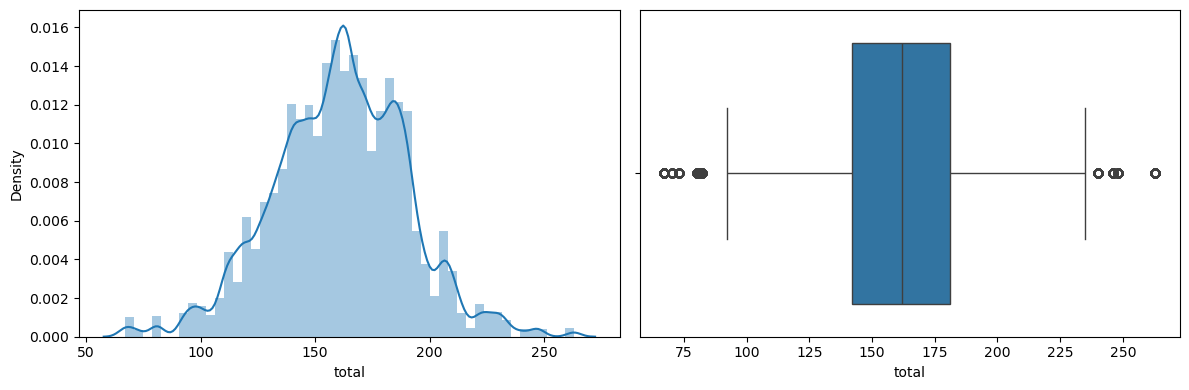

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['total'])
plt.subplot(1, 2, 2)
sns.boxplot(df['total'], orient='h')
plt.tight_layout()

#### Other Distribution

In [17]:
matchs_per_venue = df[['mid', 'venue']].drop_duplicates()
matchs_count = matchs_per_venue['venue'].value_counts()

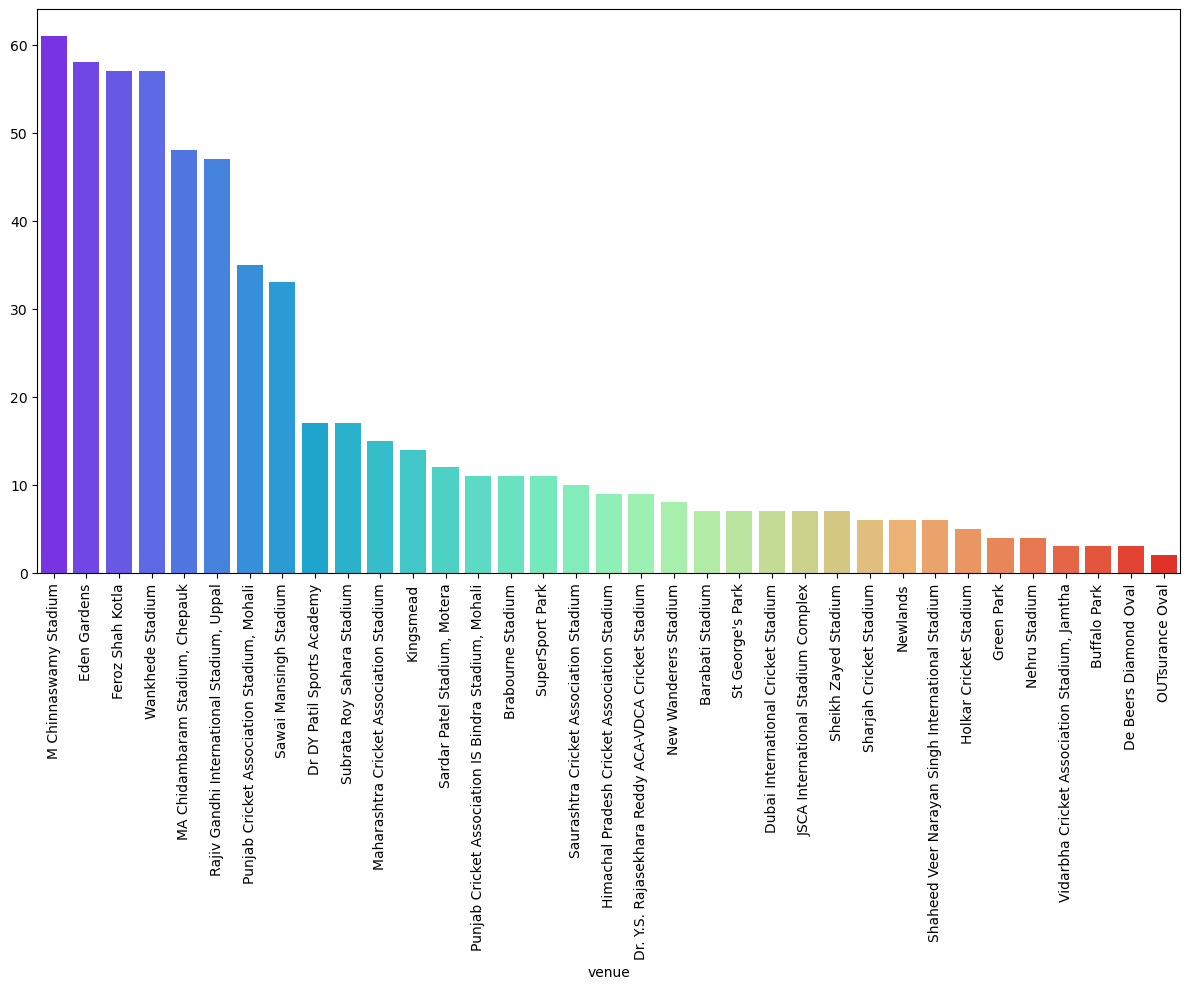

In [56]:
plt.figure(figsize=(12, 10))
sns.barplot(y=matchs_count.values, x=matchs_count.index, palette='rainbow')
plt.xticks(rotation=90)
plt.tight_layout()

In [28]:
runs_by_batsman = df.groupby('batsman')['runs'].max().sort_values(ascending=False).head(10)

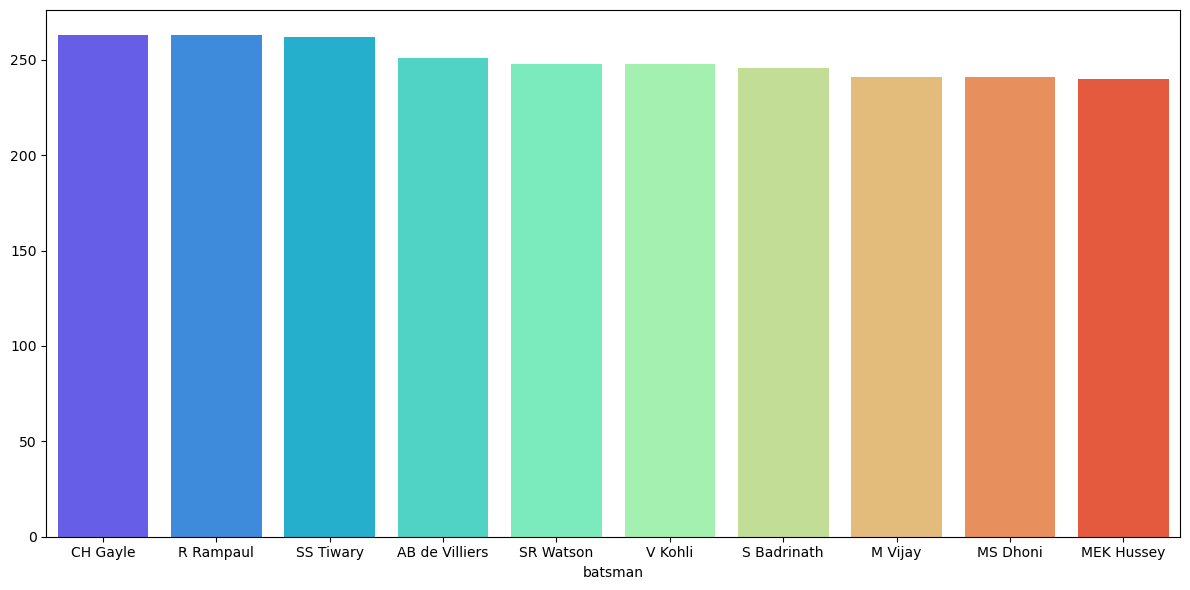

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(y=runs_by_batsman.values, x=runs_by_batsman.index, palette='rainbow')
plt.tight_layout()

In [40]:
wickets_by_bowler = df.groupby('bowler')['wickets'].max().sort_values(ascending=False).head(10)

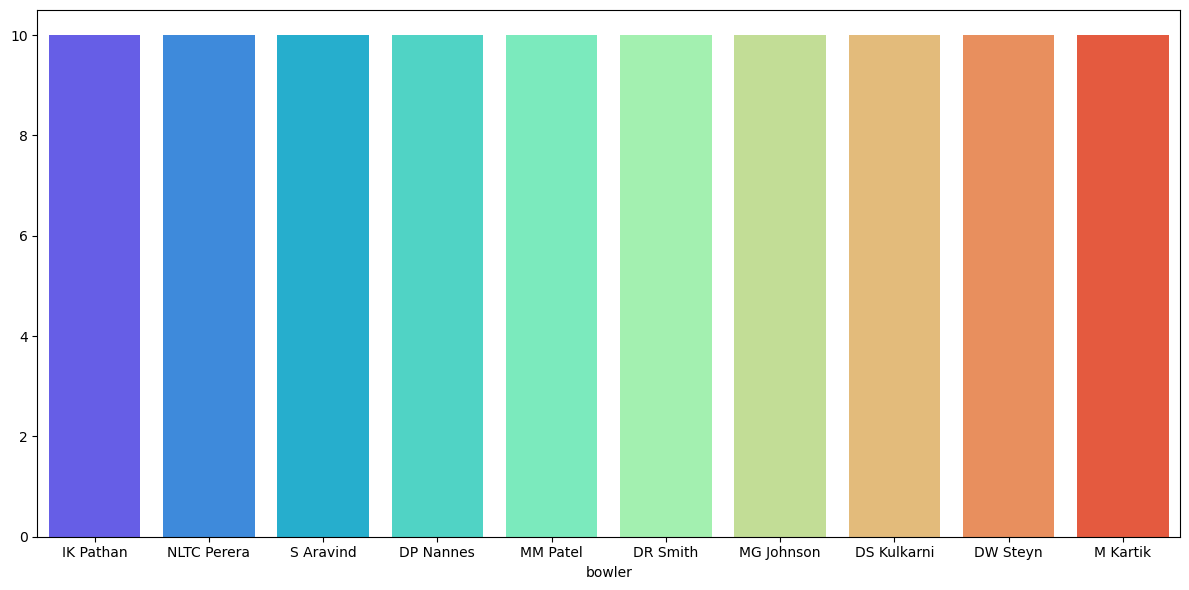

In [57]:
plt.figure(figsize=(12, 6))
sns.barplot(y=wickets_by_bowler.values, x=wickets_by_bowler.index, palette='rainbow')
plt.tight_layout()

### Step 4: Feature Engineering

#### Label Encoding

In [62]:
obj_cols = df.select_dtypes(np.object_).columns.to_list()

In [63]:
label_encoders = dict()

In [64]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#### Heat Map

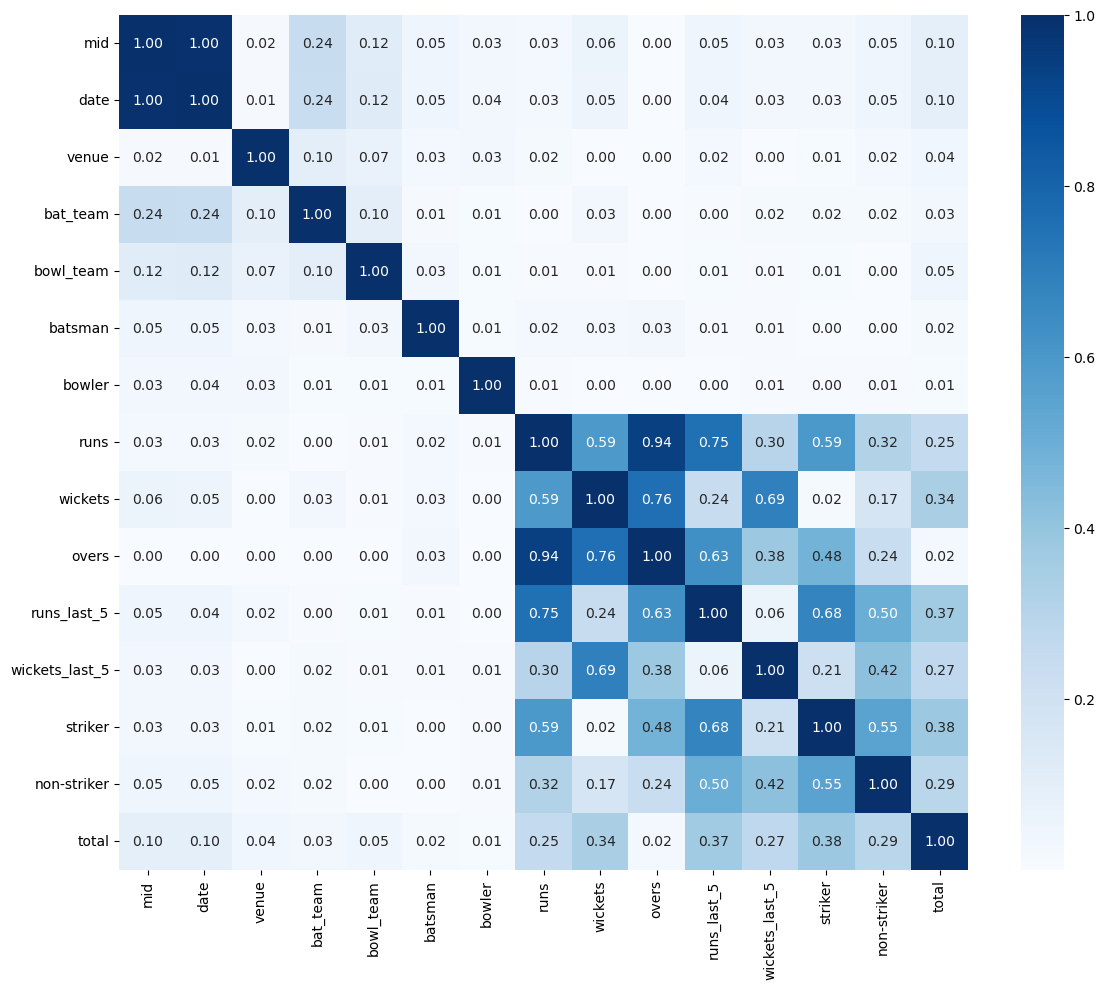

In [66]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [69]:
features = df.drop(['mid', 'date', 'total'], axis=1)
target = df['total']

In [68]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [70]:
features = selector.fit_transform(features, target)

#### Split Data

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Normalization

In [76]:
scaler = StandardScaler()

In [77]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

#### Building Model

In [98]:
inputs = layers.Input(shape=(X_train.shape[1],))
x = layers.Dense(512, activation='relu')(inputs)
x = layers.Dense(216, activation='relu')(x)
output = layers.Dense(1, activation='linear')(x)

In [99]:
model = Model(inputs, output)

In [100]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 11)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │           6,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 216)                 │         110,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │             217 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,169 (457.69 KB)

 Trainable params: 117,169 (457.69 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(
    optimizer='adam',
    loss='huber',
    metrics=[tf.keras.metrics.R2Score()]
)

#### Training Model

In [102]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 27.1525 - r2_score: -1.2625 - val_loss: 16.1329 - val_r2_score: 0.4344
Epoch 2/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 15.9813 - r2_score: 0.4471 - val_loss: 15.6586 - val_r2_score: 0.4606
Epoch 3/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.7188 - r2_score: 0.4598 - val_loss: 15.9690 - val_r2_score: 0.4433
Epoch 4/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.6175 - r2_score: 0.4654 - val_loss: 15.4401 - val_r2_score: 0.4752
Epoch 5/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 15.5644 - r2_score: 0.4679 - val_loss: 15.4138 - val_r2_score: 0.4708
Epoch 6/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.4950 - r2_score: 0.4703 - val_loss: 15.4601 - val_r2_score: 0.4690
Epoch 7/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.4481 - r2_score: 0.4723 - val_loss: 15.6052 - val_r2_score: 0.4604
Epoch 8/10
761/761 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 15.3979 - r2_score: 0.4767 - 

#### Testing Model

In [107]:
y_pred = model.predict(X_test)

476/476 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step


#### Evaluate Model

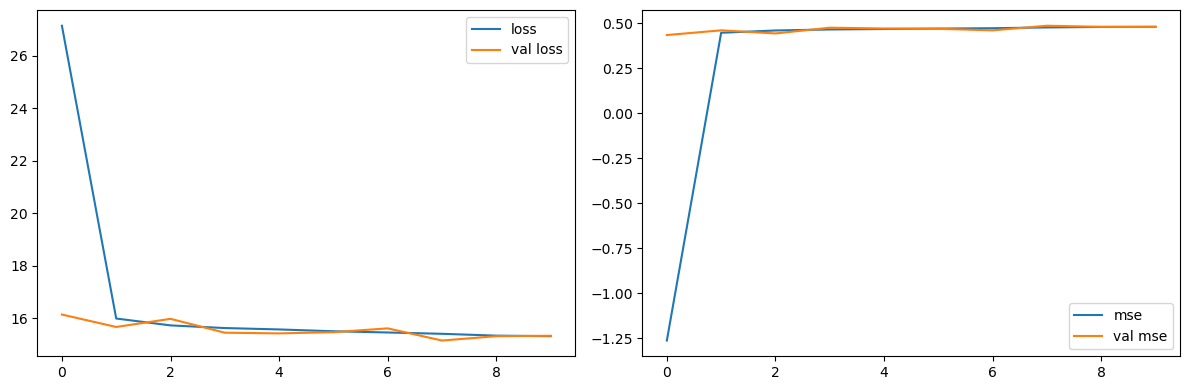

In [106]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['r2_score'], label='mse')
plt.plot(history.history['val_r2_score'], label='val mse')
plt.legend()
plt.tight_layout()

In [109]:
mae = metrics.mean_absolute_error(y_test, y_pred)

In [110]:
print(f'Testing Mean Absolute Error is {mae}')

Testing Mean Absolute Error is 15.502116203308105


### Step 7: Creating an Interactive Widget for Score Prediction

In [111]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [114]:
venue = widgets.Dropdown(
    options=list(label_encoders['venue'].classes_), 
    description='Select Venue:'
)
venue.style = {'description_width': 'initial'}

In [115]:
batting_team = widgets.Dropdown(
    options=list(label_encoders['bat_team'].classes_), 
    description='Select Batting Team:'
)
batting_team.style = {'description_width': 'initial'}

In [116]:
bowling_team = widgets.Dropdown(
    options=list(label_encoders['bowl_team'].classes_),
    description='Select Bowling Team:'
)
bowling_team.style = {'description_width': 'initial'}

In [117]:
striker = widgets.Dropdown(
    options=list(label_encoders['batsman'].classes_),
    description='Select Striker:'
)
striker.style = {'description_width': 'initial'}

In [118]:
bowler = widgets.Dropdown(
    options=list(label_encoders['bowler'].classes_), 
    description='Select Bowler:'
)
bowler.style = {'description_width': 'initial'}

In [119]:
runs = widgets.IntText(
    value=0,
    description='Runs:',
    style={'description_width': 'initial'}
)

In [120]:
wickets = widgets.IntText(
    value=0,
    description='Wickets:',
    style={'description_width': 'initial'}
)

In [121]:
overs = widgets.FloatText(
    value=0.0,
    description='Overs:',
    style={'description_width': 'initial'}
)

In [122]:
striker_ind = widgets.IntText(
    value=0,
    description='Striker:',
    style={'description_width': 'initial'}
)

In [123]:
predict_button = widgets.Button(description="Predict Score")

In [124]:
output = widgets.Output()

In [125]:
def predict_score(b):
    with output:
        clear_output()
        encoded_venue = label_encoders['venue'].transform([venue.value])[0]
        encoded_batting_team = label_encoders['bat_team'].transform([batting_team.value])[0]
        encoded_bowling_team = label_encoders['bowl_team'].transform([bowling_team.value])[0]
        encoded_striker = label_encoders['batsman'].transform([striker.value])[0]
        encoded_bowler = label_encoders['bowler'].transform([bowler.value])[0]

        input_features = [
            encoded_batting_team,
            encoded_bowling_team,
            encoded_venue,
            runs.value,
            wickets.value,
            overs.value,
            striker_ind.value,
            encoded_striker,
            encoded_bowler
        ]

        input_array = np.array(input_features).reshape(1, -1)
        input_array = scaler.transform(input_array)
        predicted_score = model.predict(input_array)
        print(f"Predicted Total Runs: {int(predicted_score[0])}")

In [126]:
predict_button.on_click(predict_score)

In [131]:
display(
    venue, 
    batting_team, 
    bowling_team, 
    striker, 
    bowler,
    runs, 
    wickets, 
    overs,
    striker_ind,
    predict_button,
    output
)

Dropdown(description='Select Venue:', options=('Barabati Stadium', 'Brabourne Stadium', 'Buffalo Park', 'De Be…

Dropdown(description='Select Batting Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredev…

Dropdown(description='Select Bowling Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredev…

Dropdown(description='Select Striker:', options=('A Ashish Reddy', 'A Chandila', 'A Chopra', 'A Choudhary', 'A…

Dropdown(description='Select Bowler:', options=('A Ashish Reddy', 'A Chandila', 'A Choudhary', 'A Flintoff', '…

...

IntText(value=0, description='Wickets:', style=DescriptionStyle(description_width='initial'))

FloatText(value=0.0, description='Overs:', style=DescriptionStyle(description_width='initial'))

IntText(value=0, description='Striker:', style=DescriptionStyle(description_width='initial'))

Button(description='Predict Score', style=ButtonStyle())

Output()